In [ ]:
import numpy as np
import phate, magic
import scprep
import matplotlib.pyplot as plt
import leidenalg
import seaborn as sns

In [111]:
names = ['GSPA_QR', 'DiffusionEMD', 'GAE_att_Gcell', 'GAE_noatt_Gcell', 'MAGIC',
       'Node2Vec_Gcell', 'Signals', 'GSPA', 'GAE_att_Ggene',
       'GAE_noatt_Ggene', 'Node2Vec_Ggene']

clist = ['black', 'light yellow', 'purple', 'forest', 'mustard', 'teal',
         'berry', 'gray', 'light purple', 'light forest', 'light teal']

colors = {'mustard': '#E1AD01', 'berry': '#AC2F3D', 'teal': '#216E76', 'purple':'#502A4F', 'forest': '#065535', 'light forest': '#519167',
          'light yellow': '#E3BC81', 'light berry': '#c7505d', 'light teal': '#81ABA1', 'light purple': '#95636E', 'black': '#000000', 'gray':'#808080'}

cmap = {0: 'berry', 1:'light teal', 2:'mustard', 3:'forest', 4:'light purple'}

In [10]:
trajectory_data = np.load('../data/splatter_simulated_data.npz')
data = trajectory_data['data']
true_counts = trajectory_data['true_counts']
true_lib_size = true_counts.T.sum(axis=1)
time = trajectory_data['pseudotime'] / 10000

In [ ]:
cell_phate_op = phate.PHATE(random_state=1234)
cell_data_phate = cell_phate_op.fit_transform(data)

cell_phate_op = phate.PHATE(random_state=1234)
true_cell_data_phate = cell_phate_op.fit_transform(true_counts)

<AxesSubplot:>

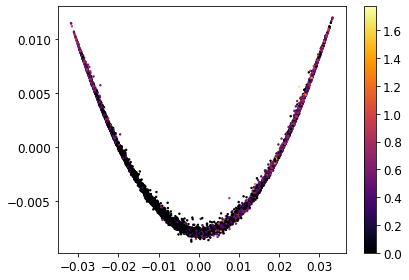

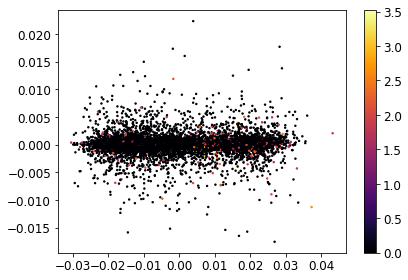

In [221]:
scprep.plot.scatter2d(true_cell_data_phate, true_counts[:, 3422], filename='figures/noiseless_gene.png', dpi=200)
scprep.plot.scatter2d(cell_data_phate, data[:, 3422], filename='figures/noisy_gene.png', dpi=200)

In [ ]:
embedding = np.load(f'../results/coexpression/GSPA_QR/0_results.npz')['signal_embedding']
gene_phate_op = phate.PHATE(random_state=1234)
gene_data_phate = gene_phate_op.fit_transform(embedding)

In [169]:
gene_clusters = phate.cluster.kmeans(gene_phate_op, n_clusters=5, random_state=1234)
gene_clusters = scprep.utils.sort_clusters_by_values(gene_clusters, gene_data_phate[:, 0])

<AxesSubplot:>

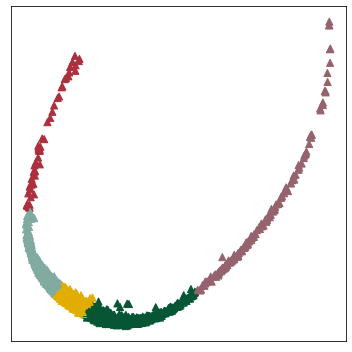

In [172]:
scprep.plot.scatter2d(gene_data_phate, marker='^',
                      c=[colors[cmap[x]] for x in gene_clusters],
                      discrete=True, s=50, ticks=None, figsize=(5,5), filename='figures/GSPA_QR_gene_clusters.png', dpi=200)

In [90]:
magic_op = magic.MAGIC(random_state=1234)
data_magic = magic_op.fit_transform(true_counts)

Calculating MAGIC...
  Running MAGIC on 10000 cells and 8821 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 11.57 seconds.
    Calculating KNN search...
    Calculated KNN search in 13.02 seconds.
    Calculating affinities...
    Calculated affinities in 15.99 seconds.
  Calculated graph and diffusion operator in 40.60 seconds.
  Running MAGIC with `solver='exact'` on 8821-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 5.72 seconds.
Calculated MAGIC in 46.41 seconds.


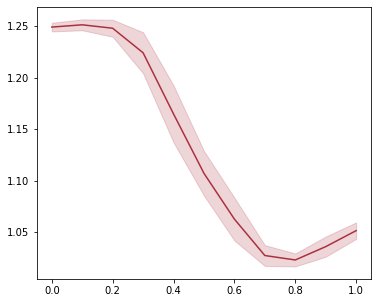

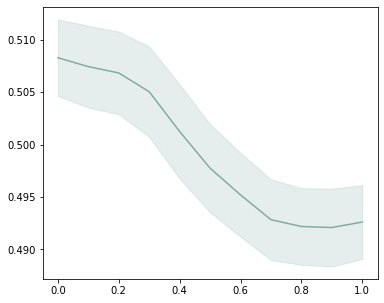

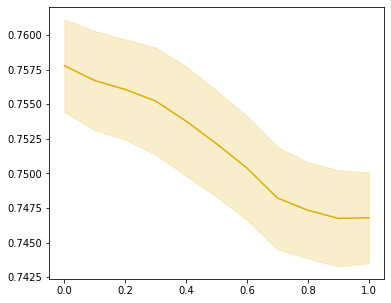

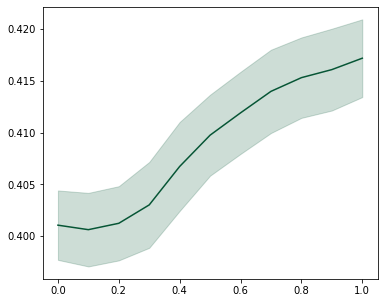

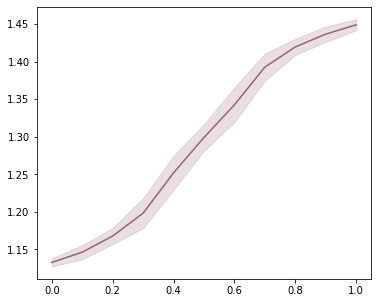

In [200]:
for c in np.unique(gene_clusters):
    fig = plt.figure(figsize=(6,5))
    signal = data_magic[:, gene_clusters == c].mean(axis=1)
    sns.lineplot(np.round(time, 1), signal, color=colors[cmap[c]], ci='sd')
    fig.savefig(f'figures/gene_cluster_{c}_over_time.png', dpi=200)

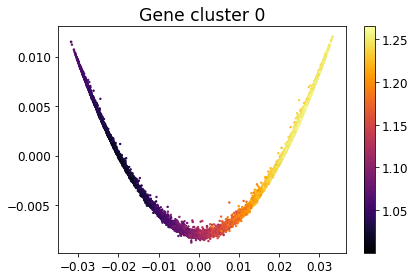

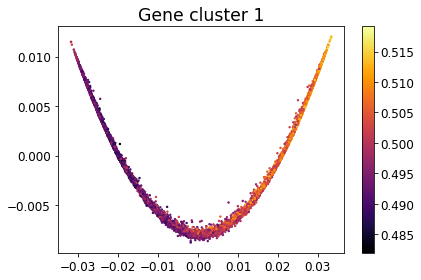

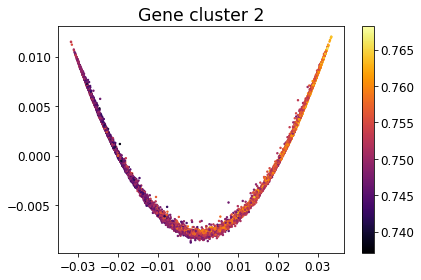

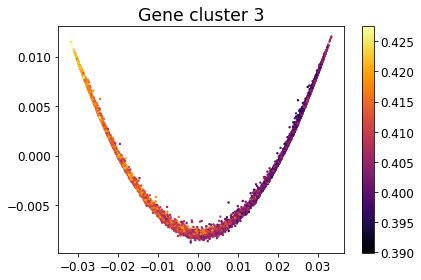

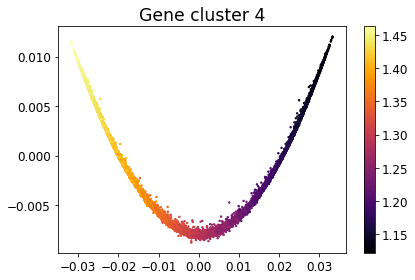

In [131]:
for c in np.unique(gene_clusters):
    scprep.plot.scatter2d(cell_data_phate,
                          c=data_magic[:, gene_clusters == c].mean(axis=1),
                          title=f'Gene cluster {c}', filename=f'figures/gene_cluster_{c}.png', dpi=200)